In [1]:
import albumentations as A
import cv2
import numpy as np

# Example pipeline (matches original doc for consistency with images)
train_transform = A.Compose([
    A.RandomCrop(width=450, height=450, p=1.0), # Example random crop
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
], bbox_params=A.BboxParams(format='yolo', # Specify input format
                           label_fields=['class_labels'] # Specify label argument name(s)
                           ))

# Load Image
image_path = "../data/incabinDetection/train/images/image5_png.rf.07b04e7d8f768ee46aae4c894fa608c9.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Prepare Bounding Boxes (example using 'yolo' format)
bboxes = np.array([
    [0.3921875, 0.6671875, 0.1203125, 0.3234375],
], dtype=np.float32)

# Prepare Labels (using the name specified in label_fields)
class_labels = np.array(['drinking'])
# Example with multiple label fields if defined in BboxParams:
# class_categories = np.array(['animal', 'animal', 'item'])

# Using train_transform defined earlier which has label_fields=['class_labels']
augmented = train_transform(image=image, bboxes=bboxes, class_labels=class_labels)

transformed_image = augmented['image']
transformed_bboxes = augmented['bboxes']
# Access transformed labels using the key from label_fields
transformed_class_labels = augmented['class_labels']

# If multiple label fields were defined (e.g., label_fields=['class_labels', 'category_id'])
# and passed like: transform(..., class_labels=..., category_id=...)
# then access them: transformed_category_ids = augmented['category_id']


import matplotlib.pyplot as plt
import random
import numpy as np # Ensure numpy is imported
import cv2 # Ensure cv2 is imported
%matplotlib inline

# Helper function to draw bounding boxes (adjust format handling as needed)
def draw_bboxes(image_np, bboxes, labels=None, class_name_map=None,
                color=(0, 255, 0), thickness=2, normalized=None):
    """
    Draw YOLO-format boxes on an image.

    Parameters
    ----------
    image_np : np.ndarray
        Image in HxWxC (uint8).
    bboxes : array-like, shape (N, 4) or (N, >=5)
        YOLO boxes as (x_center, y_center, width, height). Often normalized [0,1].
        If shape (N, >=5) and first column looks like class IDs, we use [:,1:5] as boxes
        and (optionally) [:,0] as labels if labels is None or mismatched.
    labels : array-like, optional
        Per-box labels (class indices or names). If None/mismatched and bboxes have a
        leading class column, that column is used as labels.
    class_name_map : dict, optional
        Maps label (int/str) -> display name.
    color : tuple
        BGR color for rectangles.
    thickness : int
        Rectangle line thickness.
    normalized : bool or None
        If True, interpret xywh as normalized [0,1]. If False, treat as pixel units.
        If None, auto-detect (<=1 -> normalized).

    Returns
    -------
    np.ndarray
        Image with boxes drawn.
    """
    img_res = image_np.copy()
    H, W = img_res.shape[:2]

    # Coerce to arrays
    bboxes = np.asarray(bboxes)
    if bboxes.ndim != 2 or bboxes.shape[1] < 4:
        print(f"Warning: bboxes must be Nx4+ (got shape {bboxes.shape}).")
        return img_res

    # If labels not provided (or length mismatch) and bboxes look like [cls, x, y, w, h]
    inferred_class_col = None
    if bboxes.shape[1] >= 5 and (labels is None or len(labels) != len(bboxes)):
        # Heuristic: first col integer-like and remaining cols look like xywh
        first_col = bboxes[:, 0]
        rest = bboxes[:, 1:5]
        if np.issubdtype(first_col.dtype, np.integer) or np.all(np.mod(first_col, 1) == 0):
            inferred_class_col = first_col.astype(int)
            bboxes = rest  # use [:,1:5] as xywh
            labels = inferred_class_col

    # Ensure labels array
    if labels is None:
        labels = np.array([''] * len(bboxes))
    elif not isinstance(labels, np.ndarray):
        labels = np.asarray(labels)

    # Handle object dtype -> strings
    if labels.dtype == object:
        labels = labels.astype(str)

    # Decide normalization if not given
    xywh = bboxes[:, :4].astype(float)
    if normalized is None:
        normalized = np.all(xywh <= 1.0 + 1e-6)  # treat as normalized if everything <= 1

    # Convert YOLO (xc, yc, w, h) -> pixel xyxy
    if normalized:
        xc = xywh[:, 0] * W
        yc = xywh[:, 1] * H
        ww = xywh[:, 2] * W
        hh = xywh[:, 3] * H
    else:
        xc, yc, ww, hh = xywh[:, 0], xywh[:, 1], xywh[:, 2], xywh[:, 3]

    x_min = np.round(xc - ww / 2.0).astype(int)
    y_min = np.round(yc - hh / 2.0).astype(int)
    x_max = np.round(xc + ww / 2.0).astype(int)
    y_max = np.round(yc + hh / 2.0).astype(int)

    # Clamp to image bounds
    x_min = np.clip(x_min, 0, W - 1)
    y_min = np.clip(y_min, 0, H - 1)
    x_max = np.clip(x_max, 0, W - 1)
    y_max = np.clip(y_max, 0, H - 1)

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    font_thickness = 1

    for i, (xmin, ymin, xmax, ymax, label) in enumerate(zip(x_min, y_min, x_max, y_max, labels)):
        if xmax <= xmin or ymax <= ymin:
            # Skip degenerate box
            continue

        cv2.rectangle(img_res, (xmin, ymin), (xmax, ymax), color, thickness)

        # Map label -> display name if provided
        label_key = label
        # If label looks like an integer in string form, cast for dict lookup
        if isinstance(label_key, str) and label_key.isdigit():
            label_key = int(label_key)

        label_name = str(label) if class_name_map is None else class_name_map.get(label_key, str(label))

        if label_name:
            (tw, th), bl = cv2.getTextSize(label_name, font, font_scale, font_thickness)
            # Draw filled background for readability
            text_x = int(xmin)
            text_y = int(max(0, ymin - th - 2))
            cv2.rectangle(img_res, (text_x, text_y), (text_x + tw + 2, text_y + th + 2), color, -1)
            cv2.putText(img_res, label_name, (text_x + 1, text_y + th + 1), font, font_scale, (0, 0, 0), font_thickness, cv2.LINE_AA)

    return img_res

def visualize_bbox_augmentations(image, bboxes, labels, transform, samples=5):
    """Visualizes original image and augmented versions."""
    # Prepare visualization pipeline (strip Normalize, ToTensor)
    vis_transform = None
    if isinstance(transform, A.Compose):
        vis_transform_list = [
            t for t in transform
        ]
        # Recreate Compose with original bbox_params if they exist
        # Access bbox_params from the processor if it exists
        bbox_processor = transform.processors.get('bboxes')
        bbox_params = bbox_processor.params if bbox_processor else None
        vis_transform = A.Compose(vis_transform_list, bbox_params=bbox_params)
    else:
        print("Cannot strip Normalize/ToTensor: transform is not an A.Compose instance.")
        vis_transform = transform # Use original transform

    if vis_transform is None or 'bboxes' not in vis_transform.processors:
         print("Cannot visualize: Pipeline needs A.BboxParams for visualization.")
         return

    figure, ax = plt.subplots(1, samples + 1, figsize=(15, 5))

    # Draw original
    original_drawn = draw_bboxes(image, bboxes, labels)
    ax[0].imshow(original_drawn)
    ax[0].set_title("Original")
    ax[0].axis("off")

    # Draw augmented samples
    for i in range(samples):
        try:
            # Apply the visualization transform
            # Ensure labels are passed correctly based on label_fields
            bbox_processor = vis_transform.processors.get('bboxes')
            label_fields = bbox_processor.params.label_fields if bbox_processor else []
            label_args = {field: labels for field in label_fields}
            augmented = vis_transform(image=image, bboxes=bboxes, **label_args)

            aug_image = augmented['image']
            aug_bboxes = augmented['bboxes']
            # Extract labels correctly based on label_fields
            if label_fields:
                aug_labels = augmented[label_fields[0]]
            else:
                aug_labels = ['?' for _ in aug_bboxes] # Placeholder if no labels

            augmented_drawn = draw_bboxes(aug_image, aug_bboxes, aug_labels)
            ax[i+1].imshow(augmented_drawn)
            ax[i+1].set_title(f"Augmented {i+1}")
        except Exception as e:
            print(f"Error during augmentation sample {i+1}: {e}")
            ax[i+1].imshow(image) # Show original on error
            ax[i+1].set_title(f"Aug Error {i+1}")
        finally:
            ax[i+1].axis("off")

    plt.tight_layout()
    plt.show()

# --- Example Usage --- #
# Assuming 'image', 'bboxes', 'class_labels', and 'train_transform' are defined as in Step 3/4

# Load a sample image and annotations
# image = cv2.imread('your_image.jpg')
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# bboxes = [[...], [...]] # In 'coco' format for this example
# class_labels = ['label1', 'label2']

# Define the transform (must include bbox_params with correct format and label_fields)
# train_transform = A.Compose([
#     A.RandomCrop(width=450, height=450, p=1.0),
#     A.HorizontalFlip(p=0.5),
#     A.RandomBrightnessContrast(p=0.2),
#     # A.Normalize(...), # Include if used, will be stripped by visualize func
#     # A.ToTensorV2(),  # Include if used, will be stripped by visualize func
# ], bbox_params=A.BboxParams(format='coco', label_fields=['class_labels']))

# Visualize
# visualize_bbox_augmentations(image, bboxes, class_labels, train_transform, samples=4)



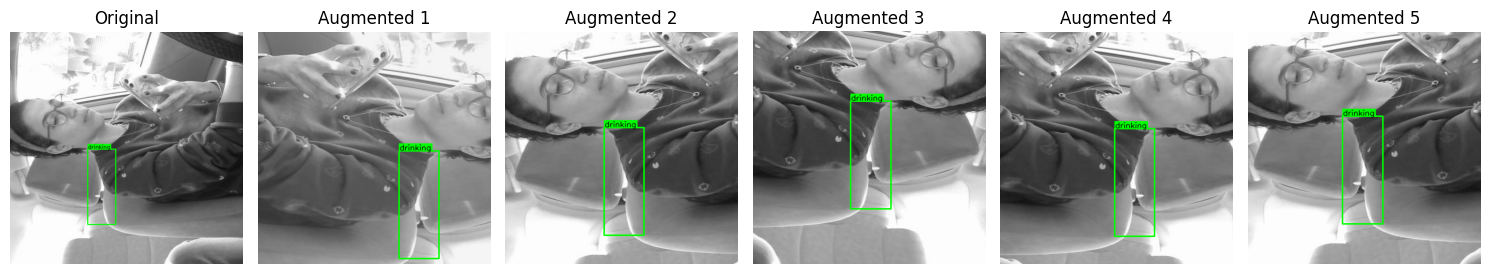

In [2]:
train_transform = A.Compose([
    A.RandomCrop(width=450, height=450, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    # A.Normalize(...), # Include if used, will be stripped by visualize func
    # A.ToTensorV2(),  # Include if used, will be stripped by visualize func
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))
visualize_bbox_augmentations(image, bboxes, class_labels,train_transform)


In [12]:
import os

train_path = "../data/incabinDetection/train/labels"
val_path = "../data/incabinDetection/valid/labels"
test_path = "../data/incabinDetection/test/labels"

def label_count(label_path:str) -> list:
    counter = [0] * 4
    for label in os.listdir(label_path):
        file_path = label_path + '/' + label

        with open(file_path, "r") as f:
            for line in f:
                counter[int(line.split(' ')[0])] += 1

    return counter

train_label_counts = label_count(train_path)
val_label_counts = label_count(val_path)
test_label_counts = label_count(test_path)

print(f"Train label counter: {train_label_counts}")
print(f"val label counter  : {val_label_counts}")
print(f"test label counter : {test_label_counts}")

Train label counter: [1817, 1816, 1788, 1765]
val label counter  : [174, 146, 119, 87]
test label counter : [88, 430, 706, 839]


In [4]:
# Train label counter: [1817, 1450, 1150, 978]
# val label counter  : [174, 146, 119, 87]
# test label counter : [88, 69, 65, 49]

In [5]:
def num_to_create(label_count:list) -> list:
    max_count = max(label_count)
    need_create = []
    for val in label_count:
        need_create.append(max_count - val)

    return need_create

train_create = num_to_create(train_label_counts)
val_create = num_to_create(val_label_counts)
test_create = num_to_create(test_label_counts)

print(f"Train label create: {train_create}")
print(f"val label create  : {val_create}")
print(f"test label create : {test_create}")



Train label create: [0, 367, 667, 839]
val label create  : [0, 28, 55, 87]
test label create : [751, 409, 133, 0]


In [6]:
# Train label create: [0, 4733, 1574, 5279]
# val label create  : [0, 464, 138, 514]
# test label create : [0, 237, 65, 260]

In [7]:
import pandas as pd
import numpy as np

train_img_path = "../data/incabinDetection/train/images"

df_training = pd.DataFrame({
    'image_path': train_img_path + '/' + np.array(os.listdir(train_img_path))})

df_training


,image_path
0,../data/incabinDetection/train/images/image286...
1,../data/incabinDetection/train/images/image133...
2,../data/incabinDetection/train/images/image245...
3,../data/incabinDetection/train/images/image200...
4,../data/incabinDetection/train/images/image415...
...,...
5358,../data/incabinDetection/train/images/image306...
5359,../data/incabinDetection/train/images/img_1035...
5360,../data/incabinDetection/train/images/image362...
5361,../data/incabinDetection/train/images/image163...


In [8]:
def get_label(image_path:str):
    split_str = image_path.split('/')
    file_name = split_str[-1][:-4] + ".txt"
    path = "/".join(split_str[:-2]) + "/labels/" + file_name

    cls = []
    bbox = []
    with open(path, 'r') as f:
        for line in f:
            line_split = list(map(float,line.split(" ")))

            cls.append(line_split[0])
            bbox.append(line_split[1:])

    return cls, bbox

In [9]:
labels = df_training["image_path"].apply(get_label)
df_training["cls"]= [label[0] for label in labels]
df_training["bbox"] = [label[1] for label in labels]

In [10]:
import os
from pathlib import Path
import pandas as pd
import albumentations as A
import cv2
import numpy as np

def oversampling_save_yolo(
    df: pd.DataFrame,
    num_to_create: list,
    out_images_dir: str,
    out_labels_dir: str,
    image_ext: str = ".jpg"
):
    out_images_dir = Path(out_images_dir)
    out_labels_dir = Path(out_labels_dir)
    out_images_dir.mkdir(parents=True, exist_ok=True)
    out_labels_dir.mkdir(parents=True, exist_ok=True)

    train_transform = A.Compose(
        [
            A.PadIfNeeded(min_height=450, min_width=450, border_mode=cv2.BORDER_CONSTANT, p=1.0),
            A.RandomCrop(width=450, height=450, p=1.0),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.2),
        ],
        bbox_params=A.BboxParams(
            format="yolo",
            label_fields=["class_labels"],
            min_visibility=0.0,  # raise (e.g. 0.1) if you want to drop barely visible boxes
        ),
    )

    # Make position indexing safe
    df = df.reset_index(drop=True)

    # Robust label filtering (works if cls is int or [int])
    def matches_label(v, lab):
        if isinstance(v, (list, tuple, np.ndarray)):
            return len(v) == 1 and v[0] == lab
        return v == lab

    saved = 0

    for label, num in enumerate(num_to_create):
        df_label = df[df["cls"].apply(lambda v: matches_label(v, label))].reset_index(drop=True)
        n0 = len(df_label)
        if n0 == 0:
            print(f"Skipping label {label}: no samples found.")
            continue

        for i_temp in range(num):
            i = i_temp % n0

            image_path = df_label.iloc[i]["image_path"]
            if not isinstance(image_path, str) or not os.path.exists(image_path):
                print(f"[WARN] bad/missing path: {image_path}")
                continue

            img_bgr = cv2.imread(image_path)
            if img_bgr is None:
                print(f"[WARN] cv2.imread failed: {image_path}")
                continue

            image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            bboxes = df_label.iloc[i]["bbox"]
            bboxes = np.array(bboxes, dtype=np.float32)

            # Ensure list-of-boxes
            if bboxes.ndim == 1 and bboxes.shape[0] == 4:
                bboxes = [bboxes.tolist()]
            else:
                bboxes = bboxes.tolist()

            class_labels = [label] * len(bboxes)

            augmented = train_transform(image=image, bboxes=bboxes, class_labels=class_labels)

            aug_img_rgb = augmented["image"]
            aug_bboxes = augmented["bboxes"]
            aug_labels = augmented["class_labels"]

            # If all boxes got dropped (can happen with cropping), you can skip saving:
            if len(aug_bboxes) == 0:
                continue

            # Build a unique filename
            stem = Path(image_path).stem
            new_name = f"{stem}_aug_l{label}_{i_temp:06d}"
            img_out_path = out_images_dir / f"{new_name}{image_ext}"
            lbl_out_path = out_labels_dir / f"{new_name}.txt"

            # Save image (cv2 wants BGR)
            aug_img_bgr = cv2.cvtColor(aug_img_rgb, cv2.COLOR_RGB2BGR)
            ok = cv2.imwrite(str(img_out_path), aug_img_bgr)
            if not ok:
                print(f"[WARN] failed to write image: {img_out_path}")
                continue

            # Save YOLO labels
            # Each bbox is (x_center, y_center, w, h) normalized in [0,1]
            with open(lbl_out_path, "w", encoding="utf-8") as f:
                for cls, (xc, yc, w, h) in zip(aug_labels, aug_bboxes):
                    # (optional) clamp to [0,1] just in case of tiny numeric drift
                    xc = float(np.clip(xc, 0.0, 1.0))
                    yc = float(np.clip(yc, 0.0, 1.0))
                    w  = float(np.clip(w,  0.0, 1.0))
                    h  = float(np.clip(h,  0.0, 1.0))
                    f.write(f"{int(cls)} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

            saved += 1

    print(f"Saved {saved} augmented image/label pairs.")


In [11]:
oversampling_save_yolo(
    df_training,
    train_create,
    out_images_dir="../data/incabinDetection/train/images",
    out_labels_dir="../data/incabinDetection/train/labels",
)

Saved 1791 augmented image/label pairs.
